# DLightSB: сравнение AdamW и MM

# Эксперимент 1. По 10 000 обучающих наблюдений

## 1. Постановка эксперимента

Сравниваются сходимость, время обучения и качество переноса распределения при двух способах минимизации одной функции потерь:

$$
\widehat{\mathcal L}(\theta)=\frac{1}{N_0}\sum_i\log c_\theta(x_0^{(i)})-\frac{1}{N_1}\sum_j\log v_\theta(x_1^{(j)}).
$$

### Данные

| Параметр | Значение |
|:--|:--|
| Бенчмарк | BenchmarkHD, эталонный потенциал из 5 гауссовских компонент |
| Размерность | 2 |
| Категории в каждой координате | 50 |
| Обучающие маргинальные выборки | По 10 000 объектов |
| Тестовые маргинальные выборки | По 10 000 объектов |
| Опорный процесс | Гауссовский, α = 0,02 |
| Временная дискретизация | 15 промежуточных моментов, skip = 8 |
| Seed данных / инициализации | 42 / 123 |

Маргинальные выборки независимы; парные наблюдения для обучения не используются. Данные фиксированы на всех итерациях. Инициализация использует только обучающую выборку.

### Формирование выборок

При seed = 42 создаётся один экземпляр BenchmarkHD с фиксированными параметрами опорного процесса и эталонного потенциала. Все выборки генерируются из этого экземпляра.

Исходное распределение $p_0$ — стандартное двумерное нормальное распределение после покоординатной дискретизации: 49 порогов равномерно расположены на отрезке $[-3,3]$, результат принимает значения от 0 до 49. Значения за крайними порогами попадают в крайние категории.

Целевое распределение определяется эталонным мостом:

$$
p_1(y)=\sum_x p_0(x)q^*(y\mid x).
$$

Вызов `sample_target(n)` сначала генерирует собственные $x\sim p_0$, затем $y\sim q^*(\cdot\mid x)$ и возвращает только $y$. Пять гауссовских компонент относятся к параметризации эталонного потенциала; $p_1$ получается из него и опорного процесса через мост.

| Массив | Получение | Назначение |
|:--|:--|:--|
| `train_x` | 10 000 объектов через `sample_input` | Первое слагаемое обучающего loss |
| `train_y` | 10 000 объектов через отдельные вызовы `sample_target` | Второе слагаемое обучающего loss |
| `test_x` | Новые 10 000 объектов через `sample_input` | Тестовый loss и входы генерации модели |
| `test_y` | Новые 10 000 объектов через `sample_target` | Тестовый loss и целевое распределение для метрик |
| `oracle_y` | Ещё 10 000 объектов через `sample_target` | Сравнение двух эталонных выборок для оценки выборочного шума |

Каждый массив собирается батчами не более 256 объектов. **Готовая выборка не делится на части:** train и test — независимо сгенерированные наблюдения из одних и тех же $p_0,p_1$. Соответствия между строками `train_x` и `train_y`, как и между `test_x` и `test_y`, нет. Совпадения дискретных значений между выборками допустимы; категории и состояния не разделяются на «обучающие» и «тестовые».

Для инициализации при seed = 123 выбираются 32 позиции из `train_y` без возвращения. По ним задаются начальные ядра DLightSB; начальные параметры сохраняются и одинаково используются обоими методами.

Для условной оценки выбираются 16 равномерно расположенных по индексу элементов `test_x`. Для каждого входа при seed = 456 генерируются 512 эталонных выходов через `benchmark.sample`. Это фиксированные входы; их значения могут повторяться. Данные, условные эталонные выходы, начальные параметры и матрицы опорного процесса сохраняются в `data/fixed_dlight_sb_mm.pt` и повторно не генерируются при обучении.

### Обучающая и тестовая выборки в протоколе библиотеки

DLightSB обучается по двум маргинальным выборкам: его loss содержит отдельные средние по $p_0$ и $p_1$ и не требует парной разметки. Поэтому независимая тестовая выборка согласуется с задачей оценки модели на тех же распределениях.

Стандартный `BenchmarkDataModule` использует `SampledCoupleDataset`: новые обучающие наблюдения генерируются при получении батча. Для validation и test используются сохранённые `benchmark.input_dataset` и `benchmark.target_dataset`; оба загрузчика обращаются к одному `data_val`. Таким образом, библиотека предусматривает отделение обучения от оценки, хотя отдельный третий набор для test в этом модуле не создаётся.

В данном эксперименте обучающие наблюдения фиксируются, чтобы оба оптимизатора минимизировали **одну и ту же конечновыборочную функцию**. Для MM это также позволяет проверять её монотонность между итерациями. Тестовая выборка оценивает перенос результата на новые наблюдения из исходных распределений и не участвует в обновлениях или выборе гиперпараметров.

Для задачи транспорта между заданными конечными эмпирическими распределениями train loss характеризует оптимизацию самой задачи, а test — дополнительную проверку обобщения на порождающие распределения. Новая случайная выборка задаёт другие эмпирические маргиналы; MM не обязан уменьшать их loss на каждом шаге.

### Условия сравнения

Оба метода получают одинаковые начальные параметры и используют 32 компоненты потенциала, полный обучающий набор на каждом шаге при лимите 300 обновлений. Для MM применяется остановка по допуску 1e-7. Вычисления выполняются на CPU в float64, в 4 потока. Энтропийная регуляризация отключена. Гиперпараметры заданы до оценки на тестовой выборке.

In [3]:
import os
import sys
import json
import hashlib
import subprocess
import io
from contextlib import redirect_stdout, redirect_stderr
from pathlib import Path
from time import perf_counter
from datetime import datetime

os.environ["LSE_BACKEND"] = "cpu"
root = next((p for p in (Path.cwd(), Path.cwd() / "catsbench", Path.cwd().parent)
             if (p / "src" / "methods" / "dlight_sb.py").exists()), None)
if root is None:
    raise RuntimeError("Откройте ноутбук из catsbench, notebooks или IntSystems.")
root = root.resolve()
for p in (root, root / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from scripts.prepare_mm_experiment import prepare, prepare_large
from catsbench.metrics import ShapeScore, TrendScore

torch.set_num_threads(4)
python = root / ".venv" / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
if not python.is_file():
    python = Path(sys.executable)
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    data_path = prepare()
data = torch.load(data_path, map_location="cpu", weights_only=True)
data_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()


## 2. Методы оптимизации

**AdamW:** шаг обучения 0,03, β₁ = 0,9, β₂ = 0,999, weight decay = 0.

**MM:** первое слагаемое оценивается касательной к логарифму, второе — неравенством Йенсена. В начале итерации фиксируются нормировочные коэффициенты и ответственности компонент. Затем выполняется один последовательный проход: обновляются веса смеси и ядра по координатам.

Каждое блочное обновление решает задачу

$$
\min_{z\geq0,\;\sum_s z_s=1}\sum_s a_s z_s-\sum_s b_s\log z_s.
$$

Повторяющиеся наблюдения объединяются с сохранением эмпирических частот. После каждого прохода проверяется невозрастание мажоранты и исходной функции потерь. Нормировка ядер компенсируется весами компонент, сохраняя условное распределение модели.

### Правило остановки

AdamW выполняет 300 обновлений. MM завершает обучение после первого принятого обновления, для которого

$$
|L_{t+1}-L_t|\le 10^{-7}\max(1,|L_t|),
$$

либо после 300 обновлений. Внутри каждой MM-итерации выполняется один проход по блокам. Проверяется изменение полного обучающего loss; тестовые метрики не влияют на остановку. Малое изменение loss является критерием остановки, но не доказательством достижения глобального оптимума.

В таблице результатов указываются фактическое число обновлений и причина завершения: tolerance — достигнут допуск, limit — достигнут лимит.


In [ ]:
STEPS = 20_000
MM_TOL = 1e-7

def run_experiment(data_path, experiment_name):
    run_root = root / "logs" / experiment_name / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    run_root.mkdir(parents=True)
    env = dict(os.environ, LSE_BACKEND="cpu", OMP_NUM_THREADS="4", MKL_NUM_THREADS="4",
               PYTHONIOENCODING="utf-8", PYTHONUTF8="1")
    summaries, histories, predictions = {}, {}, {}
    experiment_started = perf_counter()
    variant = "million_cpu" if experiment_name.endswith("million") else "fixed_cpu"
    for label, method in (("AdamW", "dlight_sb"), ("MM", "dlight_sb_mm")):
        out = run_root / method
        out.mkdir()
        command = [
            str(python), "-m", "scripts.run_mm_experiment", f"experiment={method}/{variant}",
            f"trainer.max_steps={STEPS}", f"trainer.max_epochs={STEPS}",
            f"data.path={Path(data_path).as_posix()}",
            f"hydra.run.dir={out.as_posix()}",
        ]
        if label == "MM":
            command.append(f"method.tol={MM_TOL}")
        started = perf_counter()
        with (out / "process.log").open("w", encoding="utf-8") as log:
            result = subprocess.run(command, cwd=root, env=env, stdout=log, stderr=subprocess.STDOUT)
        if result.returncode:
            raise RuntimeError((out / "process.log").read_text(encoding="utf-8")[-8000:])
        summary = json.loads((out / "summary.json").read_text(encoding="utf-8"))
        summary["process_seconds"] = perf_counter() - started
        summaries[label] = summary
        histories[label] = pd.read_csv(out / "history.csv")
        predictions[label] = torch.load(out / "predictions.pt", weights_only=True)
    experiment_seconds = perf_counter() - experiment_started
    (run_root / "comparison.json").write_text(
        json.dumps({"runs": summaries, "experiment_seconds": experiment_seconds}, indent=2),
        encoding="utf-8",
    )
    return run_root, summaries, histories, predictions, experiment_seconds

run_root, summaries, histories, predictions, experiment_seconds = run_experiment(
    data_path, "fixed_mm_comparison")


## 3. Метрики и время

### Какие величины рассчитаны

| Величина | Данные | Момент оценки |
|:--|:--|:--|
| Train loss | `train_x`, `train_y` | До обучения и после каждого обновления |
| Test loss | `test_x`, `test_y` | После остановки метода |
| ShapeScore и TrendScore | `test_y` и выходы модели для `test_x` | После обучения |
| ConditionalTrendScore | Эталонные и модельные выходы для 16 фиксированных тестовых входов | После обучения |

ShapeScore, TrendScore и ConditionalTrendScore на обучающей выборке в этом эксперименте не рассчитывались.

### Функция потерь на train и test

Для каждого набора $A\in\{\mathrm{train},\mathrm{test}\}$ используется одна формула:

$$
\widehat{\mathcal L}_A(\theta)
=\frac{1}{|X_A|}\sum_{x\in X_A}\log c_\theta(x)
-\frac{1}{|Y_A|}\sum_{y\in Y_A}\log v_\theta(y).
$$

Значения вычисляются унаследованными `get_log_c` и `get_log_v`, без генерации модельных выходов и без градиентов. Повторы объединяются с весами, равными их частотам; вычисление батчами по 256 уникальных объектов сохраняет среднее по всей исходной выборке. Train loss на графиках измерен после обновления; шаг 0 — до обучения. Это эмпирический функционал DLightSB, а не попарная ошибка предсказания и не непосредственно значение KL без аддитивной константы.

### Безусловные метрики

Для каждого $x_i$ из `test_x` генерируется один выход $\widehat y_i\sim q_\theta(\cdot\mid x_i)$ через `model.sample`. Полученные 10 000 выходов сравниваются с 10 000 объектами `test_y` по частотным распределениям. Строки двух массивов не считаются правильными и предсказанными парами.

Используются библиотечные метрики с `adjusted=False`. Для эмпирических распределений

$$
\operatorname{TV}(p,q)=\frac12\sum_s|p(s)-q(s)|.
$$

**ShapeScore** — среднее по координатам:

$$
\operatorname{ShapeScore}
=1-\frac1D\sum_{d=1}^D
\operatorname{TV}(\widehat p_{1,d},\widehat p_{\theta,d}).
$$

**TrendScore** — среднее аналогичного совпадения по парам различных координат. При $D=2$:

$$
\operatorname{TrendScore}
=1-\operatorname{TV}(\widehat p_1(y_1,y_2),
                     \widehat p_\theta(y_1,y_2)).
$$

Обе метрики лежат в $[0,1]$; больше — лучше. Дополнительно ShapeScore и TrendScore между `test_y` и независимой `oracle_y` показывают масштаб выборочного расхождения даже для эталонного распределения.

### Условная метрика

Для каждого из 16 фиксированных входов $a_j$ сравниваются 512 сохранённых эталонных выходов из $q^*(\cdot\mid a_j)$ и 512 выходов модели из $q_\theta(\cdot\mid a_j)$. При $D=2$ итог равен

$$
\operatorname{ConditionalTrendScore}
=\frac1{16}\sum_{j=1}^{16}
\left[1-\operatorname{TV}
\bigl(\widehat q^*(\cdot\mid a_j),
      \widehat q_\theta(\cdot\mid a_j)\bigr)\right].
$$

Эталонные условные выходы получены через `benchmark.sample(a_j)`, а не отбором похожих строк `test_y`. Это соответствует принципу условной оценки в `BenchmarkHDMetricsCallback`: генерация эталонных и модельных выходов при одном фиксированном входе. В данном эксперименте число входов ограничено 16.

Перед генерацией выходов каждого метода seed сбрасывается в 789. Эталонные данные общие; метрики остаются выборочными и зависят от случайности генерации.

### Время

Различаются три измерения времени:

- **Обновления:** суммарное время обучающих шагов, включая подготовку статистик, проверки и логирование внутри шага.
- **Обучение:** время от начала настройки эксперимента в обучающем процессе до завершения обучения, включая оценку функции потерь и накладные расходы Lightning.
- **Полный запуск:** время отдельного процесса, включая импорты, создание модели, финальные метрики и сохранение результатов.

Первый шаг включён в измерения. Подготовка фиксированных данных измеряется отдельно.

## 4. Результаты обучения

In [ ]:
assert all(s["file_sha256"] == data_hash for s in summaries.values())
assert all(s["dtype"] == "torch.float64" and s["num_threads"] == 4 for s in summaries.values())
assert summaries["AdamW"]["steps"] == STEPS
assert 1 <= summaries["MM"]["steps"] <= STEPS
for label, h in histories.items():
    n_steps = summaries[label]["steps"]
    assert len(h) == n_steps + 1 and np.array_equal(h.step, np.arange(n_steps + 1))
if summaries["MM"]["steps"] < STEPS:
    assert summaries["MM"]["stop_reason"] == "tolerance"
    mm_losses = histories["MM"].train_loss
    assert abs(mm_losses.iloc[-1] - mm_losses.iloc[-2]) <= MM_TOL * max(1, abs(mm_losses.iloc[-2])) + 1e-12
np.testing.assert_allclose(histories["AdamW"].train_loss.iloc[0],
                           histories["MM"].train_loss.iloc[0], atol=1e-12, rtol=0)
for h in histories.values():
    assert np.isfinite(h.train_loss).all()
    assert (h.update_seconds.diff().dropna() > 0).all()
assert histories["MM"].train_loss.diff().dropna().max() <= 1e-9

columns = ["steps", "train_loss", "test_loss", "ShapeScore", "TrendScore",
           "ConditionalTrendScore", "update_seconds", "training_wall_seconds", "process_seconds"]
table = pd.DataFrame(summaries).T[columns]
labels = {
    "steps": "Обновления",
    "train_loss": "Train loss",
    "test_loss": "Test loss",
    "ShapeScore": "ShapeScore",
    "TrendScore": "TrendScore",
    "ConditionalTrendScore": "ConditionalTrendScore",
    "update_seconds": "Время обновлений, с",
    "training_wall_seconds": "Время обучения, с",
    "process_seconds": "Полный запуск, с",
}
display(table.apply(pd.to_numeric).rename(columns=labels).T.round(4))

display(pd.Series({k: v["stop_reason"] for k, v in summaries.items()}, name="Причина остановки"))


NameError: name 'summaries' is not defined

## 5. Сходимость и выходное распределение

Функция потерь сопоставляется по числу обновлений, накопленному времени обновлений и времени обучения. Для оценки выборочного шума метрик также сравниваются две независимые выборки целевого распределения.

При общем временном бюджете учитываются только завершённые обновления. Бюджет равен меньшему из суммарных времён обновлений двух методов. Гистограммы выходных распределений используют общую цветовую шкалу.

ShapeScore    0.96195
TrendScore    0.86460
Name: Независимая выборка benchmark vs test (шум метрик), dtype: float64

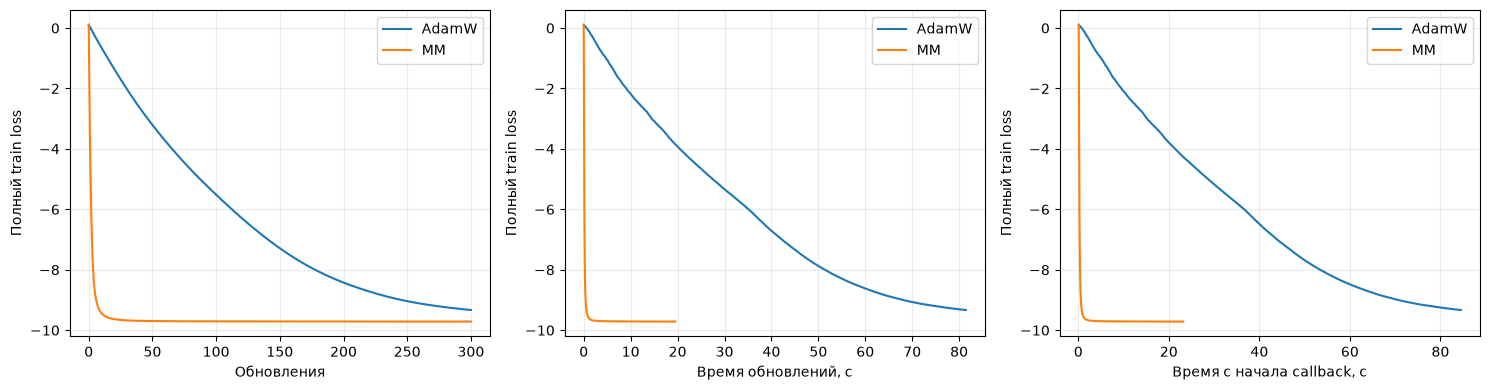

In [ ]:
oracle_scores = {}
for cls in (ShapeScore, TrendScore):
    metric = cls(dim=2, num_categories=50)
    metric.update(data["test_y"], data["oracle_y"])
    oracle_scores[cls.__name__] = metric.compute().item()
display(pd.Series(oracle_scores, name="Независимая выборка benchmark vs test (шум метрик)"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, h in histories.items():
    axes[0].plot(h.step, h.train_loss, label=label)
    axes[1].plot(h.update_seconds, h.train_loss, label=label)
    axes[2].plot(h.elapsed_seconds, h.train_loss, label=label)
for ax, xlabel in zip(axes, ("Обновления", "Время обновлений, с", "Время с начала callback, с")):
    ax.set(xlabel=xlabel, ylabel="Полный train loss")
    ax.grid(alpha=.25)
    ax.legend()
fig.tight_layout()
fig.savefig(run_root / "loss_curves.png", dpi=160)
plt.show()


Общий бюджет обновлений: 19.551 с


,step,train_loss,update_seconds
AdamW,62.0,-3.831094,19.411406
MM,300.0,-9.713416,19.550618


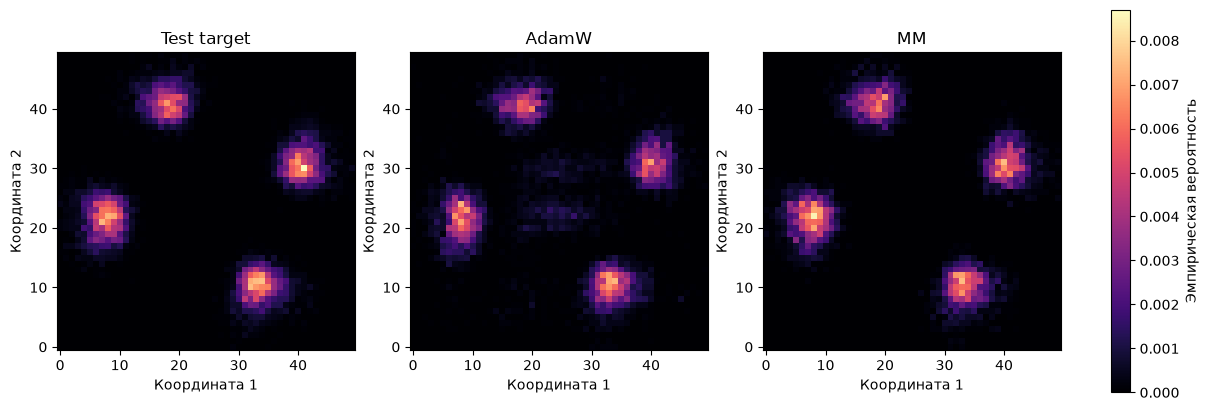

In [ ]:
# Только завершённые шаги; без интерполяции или выбора лучшего результата по test.
budget = min(h.update_seconds.iloc[-1] for h in histories.values())
equal_time = {}
for label, h in histories.items():
    row = h.loc[h.update_seconds <= budget + 1e-12].iloc[-1]
    equal_time[label] = row[["step", "train_loss", "update_seconds"]]
print(f"Общий бюджет обновлений: {budget:.3f} с")
display(pd.DataFrame(equal_time).T)

histograms = [
    np.histogram2d(y[:, 0].numpy(), y[:, 1].numpy(), bins=50,
                   range=[[-.5, 49.5], [-.5, 49.5]])[0] / len(y)
    for y in (data["test_y"], predictions["AdamW"], predictions["MM"])
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, hist, label in zip(axes, histograms, ("Test target", "AdamW", "MM")):
    im = ax.imshow(hist.T, origin="lower", extent=(-.5, 49.5, -.5, 49.5),
                   vmin=0, vmax=max(h.max() for h in histograms), cmap="magma")
    ax.set(title=label, xlabel="Координата 1", ylabel="Координата 2")
fig.colorbar(im, ax=axes, label="Эмпирическая вероятность")
fig.savefig(run_root / "target_distributions.png", dpi=160)
plt.show()
